# Exercise 8: Logistic Regression vs 1-Nearest Neighbors

## Problem Statement

Suppose that we take a data set, divide it into equally-sized training and test sets, and then try out two different classification procedures:

1. **Logistic Regression**: Error rate of 20% on training data and 30% on test data
2. **1-Nearest Neighbors (K=1)**: Average error rate of 18% (averaged over both test and training data sets)

**Question:** Based on these results, which method should we prefer to use for classification of new observations? Why?

---
## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Step 2: Understand the Given Information

In [2]:
# Given information for Logistic Regression
logreg_train_error = 0.20  # 20%
logreg_test_error = 0.30   # 30%

# Given information for 1-NN
knn1_average_error = 0.18  # 18% (average of training and test)

print("Given Information:")
print("="*50)
print(f"Logistic Regression:")
print(f"  Training Error: {logreg_train_error:.0%}")
print(f"  Test Error: {logreg_test_error:.0%}")
print(f"\n1-Nearest Neighbors (K=1):")
print(f"  Average Error (train + test): {knn1_average_error:.0%}")

Given Information:
Logistic Regression:
  Training Error: 20%
  Test Error: 30%

1-Nearest Neighbors (K=1):
  Average Error (train + test): 18%


---
## Step 3: Key Insight - Training Error for K=1 is ALWAYS 0%

**Critical Fact:** With K=1 (1-Nearest Neighbors), the training error rate is **always 0%**.

**Why?** Because each training observation is its own nearest neighbor! When we predict the class for any training point, its closest neighbor is itself, so it will always be classified correctly.

This is a fundamental property of 1-NN that we must understand.

In [3]:
# For K=1, training error is ALWAYS 0
knn1_train_error = 0.0  # 0% - each point is its own nearest neighbor!

print("Key Insight:")
print("="*50)
print("For K=1 (1-Nearest Neighbors):")
print("  - Each training observation is its own nearest neighbor")
print("  - Therefore, every training point is classified correctly")
print(f"  - Training Error = {knn1_train_error:.0%} (ALWAYS!)")

Key Insight:
For K=1 (1-Nearest Neighbors):
  - Each training observation is its own nearest neighbor
  - Therefore, every training point is classified correctly
  - Training Error = 0% (ALWAYS!)


---
## Step 4: Calculate the Test Error for 1-NN

Since the data is split into **equally-sized** training and test sets, the average error is:

$$\text{Average Error} = \frac{\text{Training Error} + \text{Test Error}}{2}$$

We can solve for the test error:

In [4]:
# Calculate test error for 1-NN
# Average = (Training + Test) / 2
# 0.18 = (0 + Test) / 2
# Test = 0.18 * 2 = 0.36

knn1_test_error = knn1_average_error * 2 - knn1_train_error

print("Calculating 1-NN Test Error:")
print("="*50)
print(f"Average Error = (Training Error + Test Error) / 2")
print(f"")
print(f"{knn1_average_error:.0%} = ({knn1_train_error:.0%} + Test Error) / 2")
print(f"")
print(f"Test Error = {knn1_average_error:.0%} × 2 - {knn1_train_error:.0%}")
print(f"")
print(f"Test Error = {knn1_test_error:.0%}")

Calculating 1-NN Test Error:
Average Error = (Training Error + Test Error) / 2

18% = (0% + Test Error) / 2

Test Error = 18% × 2 - 0%

Test Error = 36%


---
## Step 5: Compare Both Methods

In [5]:
# Create comparison table
comparison_data = {
    'Method': ['Logistic Regression', '1-NN (K=1)'],
    'Training Error': [logreg_train_error, knn1_train_error],
    'Test Error': [logreg_test_error, knn1_test_error],
    'Average Error': [
        (logreg_train_error + logreg_test_error) / 2,
        knn1_average_error
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Format as percentages
for col in ['Training Error', 'Test Error', 'Average Error']:
    comparison_df[col] = comparison_df[col].apply(lambda x: f"{x:.0%}")

print("Comparison Table:")
print("="*60)
print(comparison_df.to_string(index=False))

Comparison Table:
             Method Training Error Test Error Average Error
Logistic Regression            20%        30%           25%
         1-NN (K=1)             0%        36%           18%


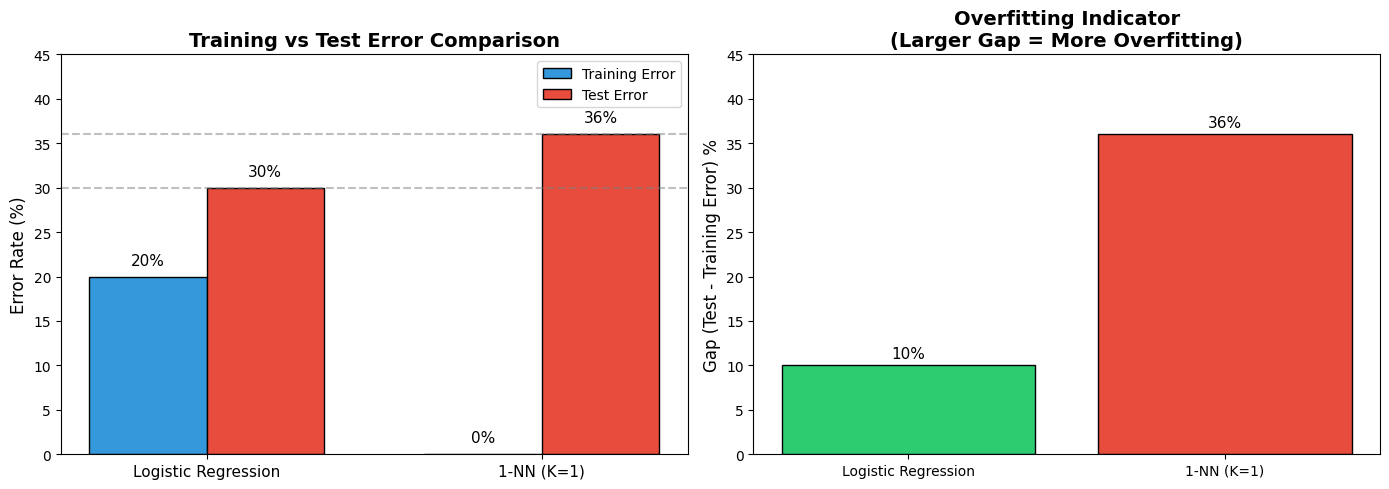

In [6]:
# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart comparison
methods = ['Logistic Regression', '1-NN (K=1)']
x = np.arange(len(methods))
width = 0.35

train_errors = [logreg_train_error * 100, knn1_train_error * 100]
test_errors = [logreg_test_error * 100, knn1_test_error * 100]

bars1 = axes[0].bar(x - width/2, train_errors, width, label='Training Error', color='#3498db', edgecolor='black')
bars2 = axes[0].bar(x + width/2, test_errors, width, label='Test Error', color='#e74c3c', edgecolor='black')

# Add value labels
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=11)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=11)

axes[0].set_ylabel('Error Rate (%)', fontsize=12)
axes[0].set_title('Training vs Test Error Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, fontsize=11)
axes[0].legend(loc='upper right')
axes[0].set_ylim(0, 45)
axes[0].axhline(y=30, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(y=36, color='gray', linestyle='--', alpha=0.5)

# Plot 2: Gap between training and test error (Overfitting indicator)
gaps = [logreg_test_error - logreg_train_error, knn1_test_error - knn1_train_error]
colors = ['#2ecc71', '#e74c3c']

bars3 = axes[1].bar(methods, [g * 100 for g in gaps], color=colors, edgecolor='black')

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=11)

axes[1].set_ylabel('Gap (Test - Training Error) %', fontsize=12)
axes[1].set_title('Overfitting Indicator\n(Larger Gap = More Overfitting)', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 45)

plt.tight_layout()
plt.show()

---
## Step 6: Analysis and Conclusion

In [7]:
print("="*70)
print("ANALYSIS")
print("="*70)

print("\n1. TEST ERROR COMPARISON (What matters for new observations):")
print("-" * 50)
print(f"   Logistic Regression: {logreg_test_error:.0%}")
print(f"   1-NN (K=1):          {knn1_test_error:.0%}")
print(f"")
print(f"   → Logistic Regression has LOWER test error ({logreg_test_error:.0%} < {knn1_test_error:.0%})")

print("\n2. OVERFITTING ANALYSIS:")
print("-" * 50)
print(f"   Logistic Regression gap: {logreg_test_error:.0%} - {logreg_train_error:.0%} = {(logreg_test_error - logreg_train_error):.0%}")
print(f"   1-NN gap:                {knn1_test_error:.0%} - {knn1_train_error:.0%} = {(knn1_test_error - knn1_train_error):.0%}")
print(f"")
print(f"   → 1-NN has a MUCH larger gap, indicating severe overfitting")
print(f"   → 1-NN memorizes training data (0% error) but fails to generalize")

print("\n3. WHY 18% AVERAGE IS MISLEADING:")
print("-" * 50)
print(f"   The 18% average includes the artificially perfect 0% training error")
print(f"   This makes 1-NN appear better than it actually is for new data")

ANALYSIS

1. TEST ERROR COMPARISON (What matters for new observations):
--------------------------------------------------
   Logistic Regression: 30%
   1-NN (K=1):          36%

   → Logistic Regression has LOWER test error (30% < 36%)

2. OVERFITTING ANALYSIS:
--------------------------------------------------
   Logistic Regression gap: 30% - 20% = 10%
   1-NN gap:                36% - 0% = 36%

   → 1-NN has a MUCH larger gap, indicating severe overfitting
   → 1-NN memorizes training data (0% error) but fails to generalize

3. WHY 18% AVERAGE IS MISLEADING:
--------------------------------------------------
   The 18% average includes the artificially perfect 0% training error
   This makes 1-NN appear better than it actually is for new data


In [8]:
print("\n" + "="*70)
print("CONCLUSION")
print("="*70)

print("""
We should prefer LOGISTIC REGRESSION for classifying new observations.

Reasons:
────────
1. LOWER TEST ERROR: Logistic regression has a test error of 30%, 
   compared to 36% for 1-NN. Since we want to classify NEW observations,
   the test error is what matters.

2. 1-NN IS OVERFITTING: The 0% training error but 36% test error shows
   that 1-NN has memorized the training data but fails to generalize.
   This is classic HIGH VARIANCE / LOW BIAS (overfitting).

3. BETTER GENERALIZATION: The smaller gap between training (20%) and 
   test (30%) error for logistic regression indicates it has learned
   the underlying pattern rather than memorizing specific data points.

4. MISLEADING AVERAGE: The 18% "average error" for 1-NN is misleading
   because it includes the artificially perfect training performance.

Final Answer:
─────────────
→ Use LOGISTIC REGRESSION (30% test error)
→ NOT 1-NN (36% test error)
""")


CONCLUSION

We should prefer LOGISTIC REGRESSION for classifying new observations.

Reasons:
────────
1. LOWER TEST ERROR: Logistic regression has a test error of 30%, 
   compared to 36% for 1-NN. Since we want to classify NEW observations,
   the test error is what matters.

2. 1-NN IS OVERFITTING: The 0% training error but 36% test error shows
   that 1-NN has memorized the training data but fails to generalize.
   This is classic HIGH VARIANCE / LOW BIAS (overfitting).

3. BETTER GENERALIZATION: The smaller gap between training (20%) and 
   test (30%) error for logistic regression indicates it has learned
   the underlying pattern rather than memorizing specific data points.

4. MISLEADING AVERAGE: The 18% "average error" for 1-NN is misleading
   because it includes the artificially perfect training performance.

Final Answer:
─────────────
→ Use LOGISTIC REGRESSION (30% test error)
→ NOT 1-NN (36% test error)



---
## Step 7: Demonstration with Simulated Data (Optional)

Let's create a simple simulation to verify our understanding:

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

# Generate synthetic data
np.random.seed(42)
X, y = make_classification(n_samples=200, n_features=10, n_informative=5, 
                           n_redundant=2, n_clusters_per_class=2, random_state=42)

# Split equally into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

print("Simulated Data:")
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Simulated Data:
Training set size: 100
Test set size: 100


In [10]:
# Fit Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

logreg_train_pred = logreg.predict(X_train)
logreg_test_pred = logreg.predict(X_test)

sim_logreg_train_error = 1 - accuracy_score(y_train, logreg_train_pred)
sim_logreg_test_error = 1 - accuracy_score(y_test, logreg_test_pred)

print("Logistic Regression Results:")
print(f"  Training Error: {sim_logreg_train_error:.2%}")
print(f"  Test Error: {sim_logreg_test_error:.2%}")

Logistic Regression Results:
  Training Error: 23.00%
  Test Error: 27.00%


In [11]:
# Fit 1-NN
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, y_train)

knn1_train_pred = knn1.predict(X_train)
knn1_test_pred = knn1.predict(X_test)

sim_knn1_train_error = 1 - accuracy_score(y_train, knn1_train_pred)
sim_knn1_test_error = 1 - accuracy_score(y_test, knn1_test_pred)
sim_knn1_avg_error = (sim_knn1_train_error + sim_knn1_test_error) / 2

print("1-NN (K=1) Results:")
print(f"  Training Error: {sim_knn1_train_error:.2%}  ← Notice this is 0%!")
print(f"  Test Error: {sim_knn1_test_error:.2%}")
print(f"  Average Error: {sim_knn1_avg_error:.2%}")

1-NN (K=1) Results:
  Training Error: 0.00%  ← Notice this is 0%!
  Test Error: 16.00%
  Average Error: 8.00%


In [12]:
# Summary of simulation
print("\n" + "="*60)
print("SIMULATION SUMMARY")
print("="*60)
print(f"\n{'Method':<25} {'Train Error':<15} {'Test Error':<15}")
print("-"*55)
print(f"{'Logistic Regression':<25} {sim_logreg_train_error:<15.2%} {sim_logreg_test_error:<15.2%}")
print(f"{'1-NN (K=1)':<25} {sim_knn1_train_error:<15.2%} {sim_knn1_test_error:<15.2%}")
print(f"\nAs expected, 1-NN has 0% training error but higher test error!")
print(f"This confirms the theoretical analysis.")


SIMULATION SUMMARY

Method                    Train Error     Test Error     
-------------------------------------------------------
Logistic Regression       23.00%          27.00%         
1-NN (K=1)                0.00%           16.00%         

As expected, 1-NN has 0% training error but higher test error!
This confirms the theoretical analysis.


---
## Summary

| Metric | Logistic Regression | 1-NN (K=1) | Winner |
|--------|--------------------:|----------:|--------|
| Training Error | 20% | 0% | 1-NN (but misleading!) |
| Test Error | **30%** | 36% | **Logistic Regression** |
| Average Error | 25% | 18% | 1-NN (but misleading!) |
| Overfitting Gap | 10% | 36% | Logistic Regression |

### Key Takeaway:

**For classifying NEW observations, we should use Logistic Regression** because:
1. It has a lower test error (30% vs 36%)
2. It generalizes better to unseen data
3. The 1-NN's 0% training error is artificially perfect and doesn't reflect real-world performance